<a href="https://colab.research.google.com/github/afreensyedsadutheen-design/my_repository/blob/main/Student_Performance_Prediction_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Performance Prediction Using Machine Learning

**Algorithm:** Decision Tree Classification

This Google Colab notebook contains:
- Dataset creation
- Data preprocessing
- Pass/Fail distribution graph
- Train-test split
- Decision Tree training
- Decision Tree visualization
- Accuracy
- Classification report
- Confusion matrix
- New student prediction

> The included dataset is a small illustrative dataset so the notebook can run immediately without uploading a separate CSV file.


## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


## 2. Create the Dataset

In [2]:
data = {
    "Attendance": [85, 60, 90, 55, 75, 95, 65, 80, 50, 88,
                   92, 70, 45, 78, 82, 58, 96, 68, 73, 87,
                   62, 91, 77, 54, 89, 69, 94, 57, 81, 71,
                   86, 63, 97, 59, 76, 83, 67, 93, 52, 79, 84],
    "Study_Hours": [4, 2, 5, 1, 3, 6, 2, 4, 1, 5,
                    6, 3, 1, 4, 5, 2, 6, 3, 3, 5,
                    2, 5, 4, 1, 5, 3, 6, 2, 4, 3,
                    5, 2, 6, 1, 4, 5, 3, 6, 1, 4, 5],
    "Previous_Marks": [78, 45, 88, 40, 65, 92, 50, 75, 35, 82,
                       90, 60, 38, 72, 80, 48, 95, 55, 68, 85,
                       52, 89, 74, 42, 86, 62, 93, 47, 76, 66,
                       84, 54, 96, 41, 70, 81, 58, 91, 36, 73, 87],
    "Assignment_Score": [80, 50, 92, 45, 70, 95, 55, 78, 40, 85,
                         94, 65, 42, 75, 88, 52, 96, 60, 72, 90,
                         56, 91, 79, 48, 89, 68, 97, 51, 80, 70,
                         86, 58, 98, 44, 74, 85, 63, 94, 39, 77, 92],
    "Internal_Marks": [75, 42, 85, 38, 68, 90, 48, 72, 35, 80,
                       88, 58, 35, 70, 82, 45, 92, 52, 65, 84,
                       50, 87, 72, 40, 85, 60, 94, 43, 74, 64,
                       82, 52, 95, 37, 69, 79, 55, 90, 34, 71, 86],
    "Result": ["Pass", "Fail", "Pass", "Fail", "Pass", "Pass", "Fail", "Pass", "Fail", "Pass",
               "Pass", "Pass", "Fail", "Pass", "Pass", "Fail", "Pass", "Fail", "Pass", "Pass",
               "Fail", "Pass", "Pass", "Fail", "Pass", "Pass", "Pass", "Fail", "Pass", "Pass",
               "Pass", "Fail", "Pass", "Fail", "Pass", "Pass", "Fail", "Pass", "Fail", "Pass", "Pass"]
}

df = pd.DataFrame(data)

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (41, 6)


,Attendance,Study_Hours,Previous_Marks,Assignment_Score,Internal_Marks,Result
0,85,4,78,80,75,Pass
1,60,2,45,50,42,Fail
2,90,5,88,92,85,Pass
3,55,1,40,45,38,Fail
4,75,3,65,70,68,Pass


## 3. Check Dataset Information and Missing Values

In [3]:
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Attendance        41 non-null     int64 
 1   Study_Hours       41 non-null     int64 
 2   Previous_Marks    41 non-null     int64 
 3   Assignment_Score  41 non-null     int64 
 4   Internal_Marks    41 non-null     int64 
 5   Result            41 non-null     object
dtypes: int64(5), object(1)
memory usage: 2.1+ KB
None

Missing Values:
Attendance          0
Study_Hours         0
Previous_Marks      0
Assignment_Score    0
Internal_Marks      0
Result              0
dtype: int64


## 4. Convert Pass/Fail into Numerical Values

In [4]:
df["Result"] = df["Result"].map({
    "Fail": 0,
    "Pass": 1
})

print(df.head())


   Attendance  Study_Hours  Previous_Marks  Assignment_Score  Internal_Marks  \
0          85            4              78                80              75   
1          60            2              45                50              42   
2          90            5              88                92              85   
3          55            1              40                45              38   
4          75            3              65                70              68   

   Result  
0       1  
1       0  
2       1  
3       0  
4       1  


## 5. Pass vs Fail Distribution

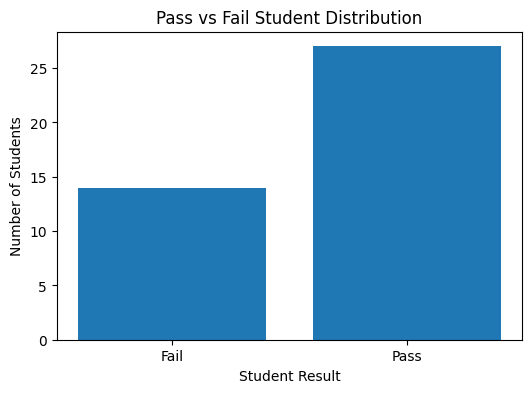

Fail: 14
Pass: 27


In [5]:
counts = df["Result"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Fail", "Pass"], counts.values)
plt.xlabel("Student Result")
plt.ylabel("Number of Students")
plt.title("Pass vs Fail Student Distribution")
plt.show()

print("Fail:", counts.get(0, 0))
print("Pass:", counts.get(1, 0))


## 6. Input Features and Target

In [6]:
X = df[
    [
        "Attendance",
        "Study_Hours",
        "Previous_Marks",
        "Assignment_Score",
        "Internal_Marks"
    ]
]

y = df["Result"]

print("Input Features:")
print(X.head())

print("\nTarget:")
print(y.head())


Input Features:
   Attendance  Study_Hours  Previous_Marks  Assignment_Score  Internal_Marks
0          85            4              78                80              75
1          60            2              45                50              42
2          90            5              88                92              85
3          55            1              40                45              38
4          75            3              65                70              68

Target:
0    1
1    0
2    1
3    0
4    1
Name: Result, dtype: int64


## 7. Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (32, 5)
Testing Data: (9, 5)


## 8. Train Decision Tree Model

In [8]:
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Training Completed!")


Model Training Completed!


## 9. Decision Tree Visualization

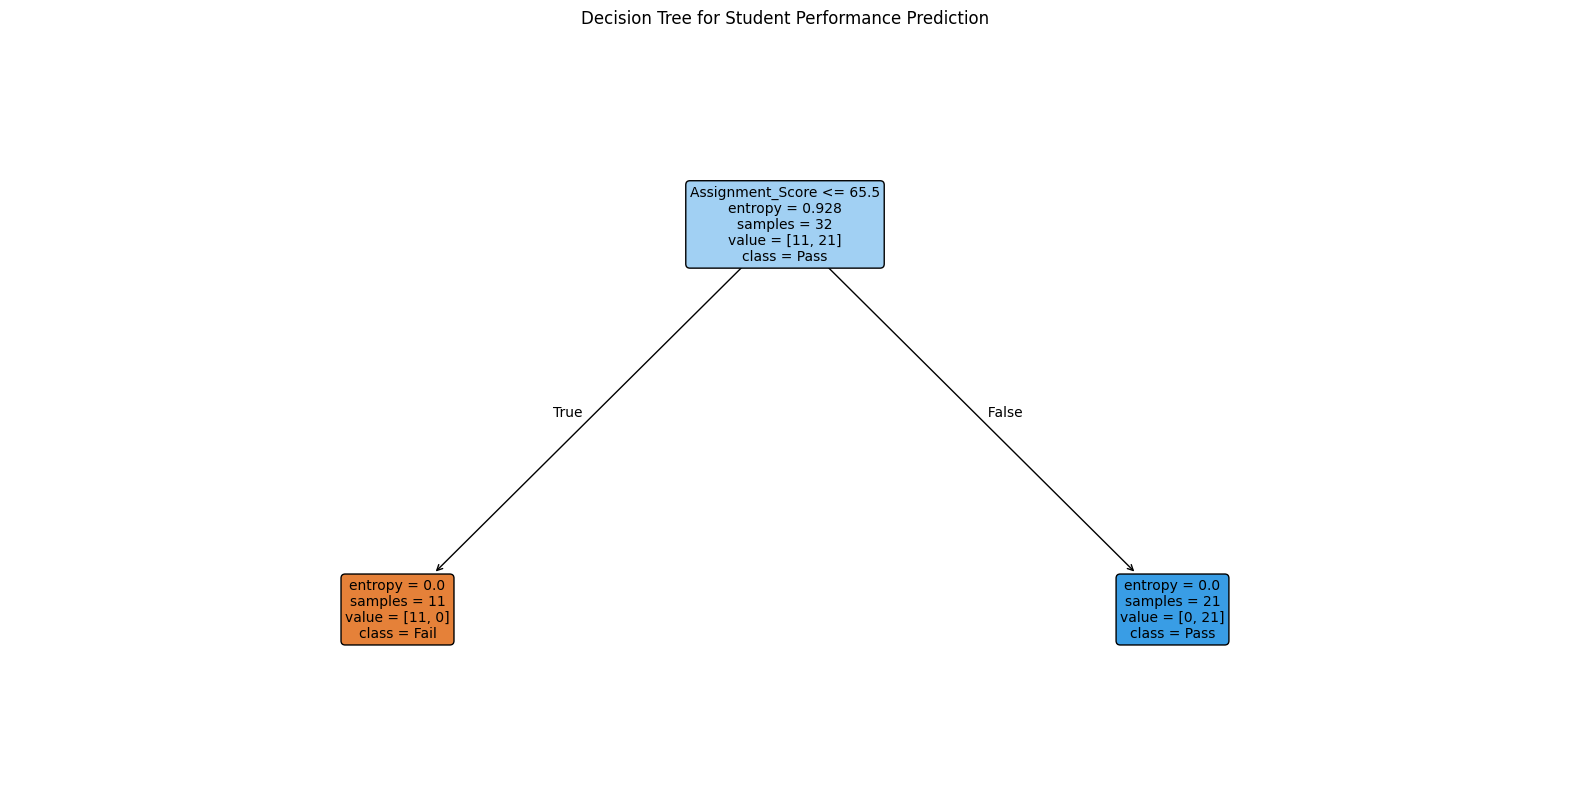

In [9]:
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree for Student Performance Prediction")
plt.show()


## 10. Make Predictions

In [10]:
y_pred = model.predict(X_test)

print("Actual Results:   ", y_test.to_numpy())
print("Predicted Results:", y_pred)


Actual Results:    [0 0 1 1 1 1 1 1 0]
Predicted Results: [0 0 1 1 1 1 1 0 0]


## 11. Calculate Accuracy

In [11]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")


Model Accuracy: 88.89%


## 12. Classification Report

In [12]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Fail", "Pass"]
))


              precision    recall  f1-score   support

        Fail       0.75      1.00      0.86         3
        Pass       1.00      0.83      0.91         6

    accuracy                           0.89         9
   macro avg       0.88      0.92      0.88         9
weighted avg       0.92      0.89      0.89         9



## 13. Confusion Matrix

Confusion Matrix:
[[3 0]
 [1 5]]


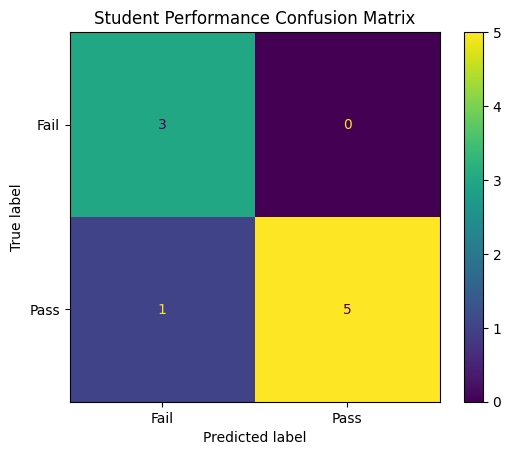

In [13]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)

disp.plot()
plt.title("Student Performance Confusion Matrix")
plt.show()


## 14. Predict a New Student

In [14]:
def predict_student(attendance, study_hours,
                    previous_marks, assignment_score,
                    internal_marks):

    student = pd.DataFrame([{
        "Attendance": attendance,
        "Study_Hours": study_hours,
        "Previous_Marks": previous_marks,
        "Assignment_Score": assignment_score,
        "Internal_Marks": internal_marks
    }])

    prediction = model.predict(student)[0]

    if prediction == 0:
        return "FAIL"
    else:
        return "PASS"


### Example: New Student

In [15]:
result = predict_student(
    attendance=85,
    study_hours=4,
    previous_marks=78,
    assignment_score=80,
    internal_marks=75
)

print("Student Performance:", result)


Student Performance: PASS


## 15. Try Your Own Student

In [16]:
# Change these values and run the cell again.

attendance = 90
study_hours = 5
previous_marks = 85
assignment_score = 88
internal_marks = 82

result = predict_student(
    attendance,
    study_hours,
    previous_marks,
    assignment_score,
    internal_marks
)

print("Student Performance:", result)


Student Performance: PASS


## 16. Result

The Student Performance Prediction system was successfully developed using a Decision Tree Classification algorithm. The model uses attendance, study hours, previous marks, assignment score, and internal marks to predict whether a student is likely to Pass or Fail.

**Note:** The included dataset is illustrative. For an academic submission, replace it with your approved real dataset if your faculty requires an external dataset.
